In [1]:
import numpy as np
import matplotlib.pyplot as plt
import snag
import qse

25


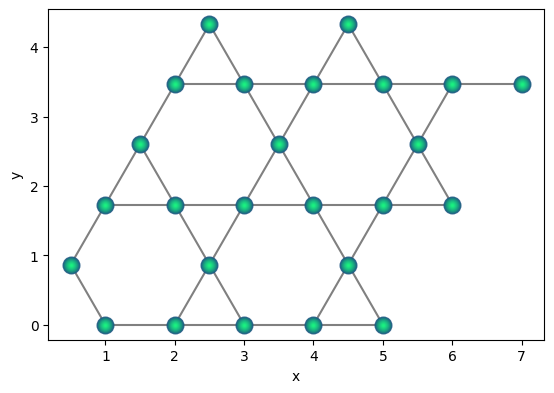

In [2]:
qbits = qse.lattices.kagome(1.0, 3, 3)
# qbits = qse.lattices.hexagonal(1., 4, 4)
# n_sites = 10

# qbits_a = qse.lattices.chain(1., n_sites)
# qbits_a.add_dim()
# qbits_b = qse.lattices.chain(1., n_sites)
# qbits_b.add_dim()
# qbits_b.translate((0.5, np.sqrt(3)/2))

# qbits = qbits_a + qbits_b
del qbits[[0, -1]]

print(qbits.nqbits)
qbits.draw(radius="nearest")

In [3]:
# n_sites = 24

# qbits = qse.lattices.chain(1., n_sites)
# #qbits = qse.lattices.ring(1., n_sites)
# qbits.draw(radius="nearest")

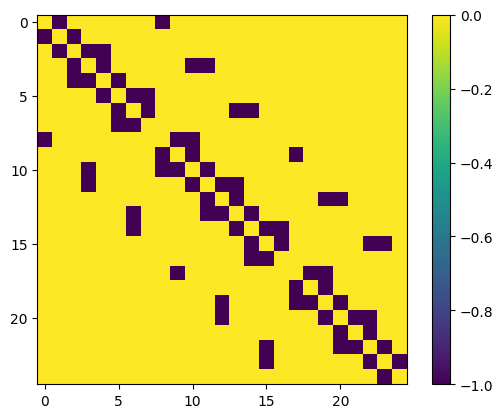

In [4]:
# fac = 1.
# t_mat = -np.exp(-fac*(1.-qbits.get_all_distances())**2)
# np.fill_diagonal(t_mat, 0.)

t_mat = -qbits.get_adjacency_matrix(1.0)
plt.imshow(t_mat)
plt.colorbar()
plt.show()

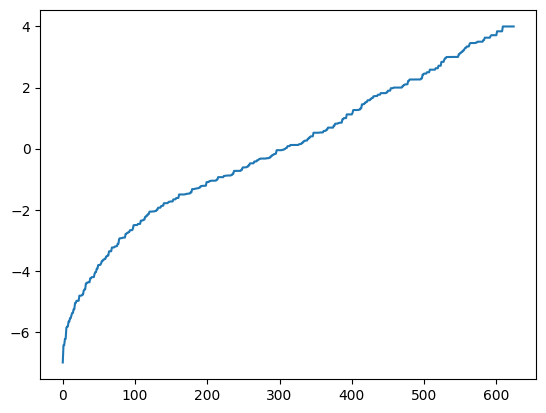

In [5]:
calc_ni = snag.NonInteracting(t_mat)
plt.plot(calc_ni.full_spectrum(1, 1))

2.0000000000000036
1.999999999999999
2.0000000000000004
1.9999999999999962
2.0000000000000004
1.9999999999999944


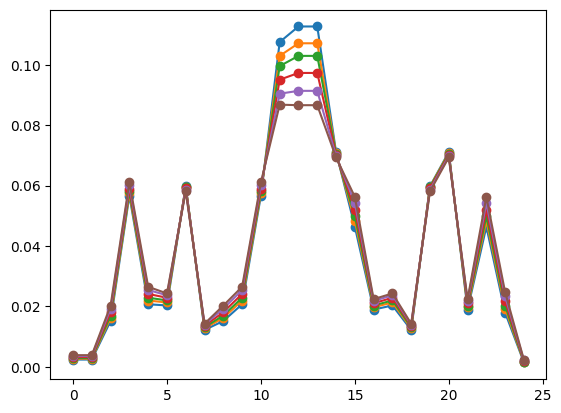

In [26]:
calc = snag.Hubbard(n_up=1, n_dn=1, n_sites=qbits.nqbits)
# print(calc.dim)
h_t = calc.hopping(t_mat)
h_u = calc.n_up_n_dn()

# h_u
# calc.basis
us = [0, 1, 2, 4, 8, 16]
data = []
densities = []

for u in us:
    ham = h_t + u * np.diag(h_u)

    result = np.linalg.eigh(ham)

    probs = result.eigenvectors[:, 0] ** 2
    density = (probs[:, None, None] * calc.basis).sum(0)

    print(density.sum())
    data.append((probs * h_u).sum())
    densities.append(density)

    plt.plot(density[0], marker="o")

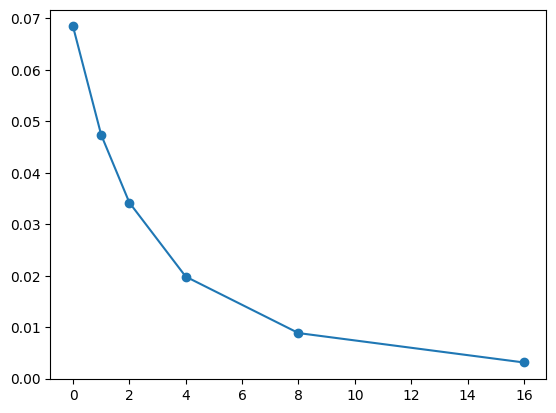

In [7]:
plt.plot(us, data, marker="o")

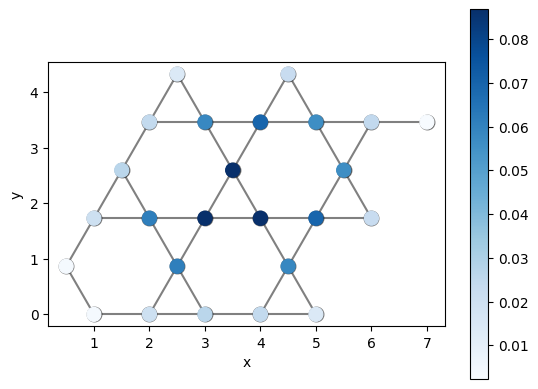

In [9]:
qse.vis.qbits_heatmap(qbits, densities[-1][0], radius="nearest")

In [20]:
densities

[array([[0.00243189, 0.00243189, 0.01519549, 0.05668691, 0.02073644,
         0.02033467, 0.05975829, 0.01223171, 0.01519549, 0.02073644,
         0.05668691, 0.10750429, 0.11265776, 0.11265776, 0.07111471,
         0.04640535, 0.01897593, 0.02033467, 0.01223171, 0.05975829,
         0.07111471, 0.01897593, 0.04640535, 0.01797015, 0.00146722],
        [0.00243189, 0.00243189, 0.01519549, 0.05668691, 0.02073644,
         0.02033467, 0.05975829, 0.01223171, 0.01519549, 0.02073644,
         0.05668691, 0.10750429, 0.11265776, 0.11265776, 0.07111471,
         0.04640535, 0.01897593, 0.02033467, 0.01223171, 0.05975829,
         0.07111471, 0.01897593, 0.04640535, 0.01797015, 0.00146722]]),
 array([[0.00271083, 0.00271083, 0.0162161 , 0.05745577, 0.02197713,
         0.02132063, 0.05959618, 0.01276158, 0.0162161 , 0.02197713,
         0.05745577, 0.10292883, 0.10709833, 0.10709833, 0.07082196,
         0.04837516, 0.01974473, 0.02132063, 0.01276158, 0.05959618,
         0.07082196, 0.0197447

In [17]:
from IPython.display import HTML

In [14]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

viridis = mpl.colormaps["viridis"]


def animate_qbits(qbits, quantity):

    # Set up the figure and axis
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_aspect("equal")
    ax.axis("off")  # Hide axes

    for i in range(qbits.nqbits - 1):
        for j in range(i + 1, qbits.nqbits):
            # if laplacian[i,j] == -1:
            ax.plot(
                [qbits[i].x, qbits[j].x],
                [qbits[i].y, qbits[j].y],
                zorder=-1,
                c="k",
                alpha=0.3,
            )

    circles = []
    for q in qbits:
        circle = plt.Circle((q.x, q.y), 0.1, color=viridis(quantity[0, q.index]))
        ax.add_patch(circle)
        circles.append(circle)

    # Animation update function
    def update(frame):
        for q in qbits:
            circles[q.index].set_color(viridis(quantity[frame, q.index]))
        return circles

    # Create the animation
    ani = FuncAnimation(
        fig,
        update,
        frames=len(quantity),
        interval=200,  # 50ms between frames
        blit=True,
    )
    return ani

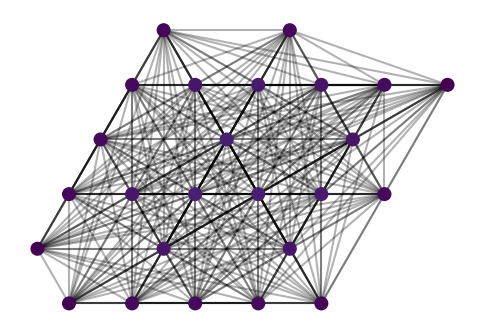

In [18]:
ani = animate_qbits(qbits, density)

HTML(ani.to_jshtml())